## AI-Powered Credit Risk Intelligence Platform - Exploratory Data Analysis

Dataset analysed: Home Credit Default Risk

## 1. Introduction & Business Understanding

**Objective:** Design and build a lightweight
AI-powered credit risk platform using the Home Credit Default Risk dataset.

**Business Context:** Banks face pressure to
make faster, more accurate, and explainable credit decisions. This
platform is meant to address real banking needs:
- Identify high-risk loan applicants early
- Automate risk scoring and decision support
- Provide explainable reasons for risk classifications
- Satisfy audit and regulatory requirements
- Let business analysts explore data in plain English
- Bridge ML insights and credit policy with rules

**Target variable:**
- TARGET = 0 -> the applicant did not experience payment difficulties
- TARGET = 1 -> the applicant experienced payment difficulties/default

### 1.1 Dataset Files

This isn't one file - it's 10 CSVs that join together like tables in a database.

**Files actually used in this notebook:**
- application_train.csv - the main table, one row per applicant, has TARGET
- bureau.csv, previous_application.csv, installments_payments.csv - brought in later (Section 20) to check credit history and repayment behaviour, since that signal isn't in the main table at all

**Not used here, but relevant later for modeling:**
- bureau_balance.csv, POS_CASH_balance.csv, credit_card_balance.csv - these need aggregation before they're useful (e.g. one applicant can have hundreds of monthly balance rows), so they're better handled in the feature engineering pipeline than in EDA
- application_test.csv has no TARGET column, so it can't be used to check model performance - a stratified split of application_train.csv is used for validation instead

**Not used at all:**
- HomeCredit_columns_description.csv - just a reference for column meanings while writing this

## 2. Import Libraries

Importing what is needed for data manipulation, numerical operations,
visualization, and statistics.

In [1]:
import os
import warnings

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

CHART_DIR = Path("../outputs/eda_charts")
CHART_DIR.mkdir(parents=True, exist_ok=True)

## 3. Load the Dataset

application_train.csv contains historical loan applications and the TARGET label

In [2]:
DATA_PATH = "../data/application_train.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset Loaded Successfully")
print("Shape:", df.shape)

Dataset Loaded Successfully
Shape: (307511, 122)


## 4. Dataset Overview

To understand: number of applicants, number of features, dataset structure, data types, and what a few sample rows actually look like.

In [3]:
print("Dataset Shape:")
print(df.shape)

print("\nFirst Five Rows:")
df.head()

Dataset Shape:
(307511, 122)

First Five Rows:


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,...,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,...,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,...,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,297000.0,Unaccompanied,Working,Secondary / secondary special,Civil marriage,House / apartment,0.008019,-19005,-3039,-9833.0,-2437,NaN,1,1,0,...,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,513000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.028663,-19932,-3038,-4311.0,-3458,NaN,1,1,0,...,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
print("Random Sample:")
df.sample(5, random_state=42)

Random Sample:


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,...,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
245895,384575,0,Cash loans,M,Y,N,2,207000.0,465457.5,52641.0,418500.0,Unaccompanied,Commercial associate,Secondary / secondary special,Married,House / apartment,0.009630,-13297,-762,-637.0,-4307,19.0,1,1,0,...,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,1.0,0.0,1.0
98194,214010,0,Cash loans,F,Y,Y,0,247500.0,1281712.5,48946.5,1179000.0,Unaccompanied,Commercial associate,Higher education,Single / not married,House / apartment,0.006852,-14778,-1141,-1610.0,-4546,11.0,1,1,0,...,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,1.0,0.0,3.0
36463,142232,0,Cash loans,F,Y,N,0,202500.0,495000.0,39109.5,495000.0,Unaccompanied,Working,Secondary / secondary special,Married,House / apartment,0.035792,-17907,-639,-2507.0,-1461,4.0,1,1,1,...,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,1.0,0.0,3.0
249923,389171,0,Cash loans,F,N,Y,0,247500.0,254700.0,24939.0,225000.0,Unaccompanied,State servant,Secondary / secondary special,Widow,House / apartment,0.046220,-19626,-6982,-11167.0,-3158,NaN,1,1,0,...,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
158389,283617,0,Cash loans,M,N,Y,0,112500.0,308133.0,15862.5,234000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018850,-20327,-1105,-7299.0,-494,NaN,1,1,0,...,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,4.0


### Data Types

In [6]:
print(df.dtypes.value_counts())

print("\nDetailed Dataset Information:")
df.info(verbose=False)

float64    65
int64      41
str        16
Name: count, dtype: int64

Detailed Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), str(16)
memory usage: 325.2 MB


The dataset contains 307,511 rows and 122 columns: 65 float64 (continuous financial/ratio values), 41 int64 (counts and flags), and 16 string/categorical columns. This mix of types is the reason features are grouped by business meaning in Section 7 rather than treated as one undifferentiated block. Memory usage is ~325 MB, small enough to work with directly in memory.

## 5. Target Variable Analysis

Understanding: number of defaults, number of non-defaults, default percentage, and class imbalance.

In [7]:
target_counts = df["TARGET"].value_counts()
target_percentage = df["TARGET"].value_counts(normalize=True) * 100

print("Target Counts:")
print(target_counts)

print("\nTarget Percentage:")
print(target_percentage)

Target Counts:
TARGET
0    282686
1     24825
Name: count, dtype: int64

Target Percentage:
TARGET
0    91.927118
1     8.072882
Name: proportion, dtype: float64


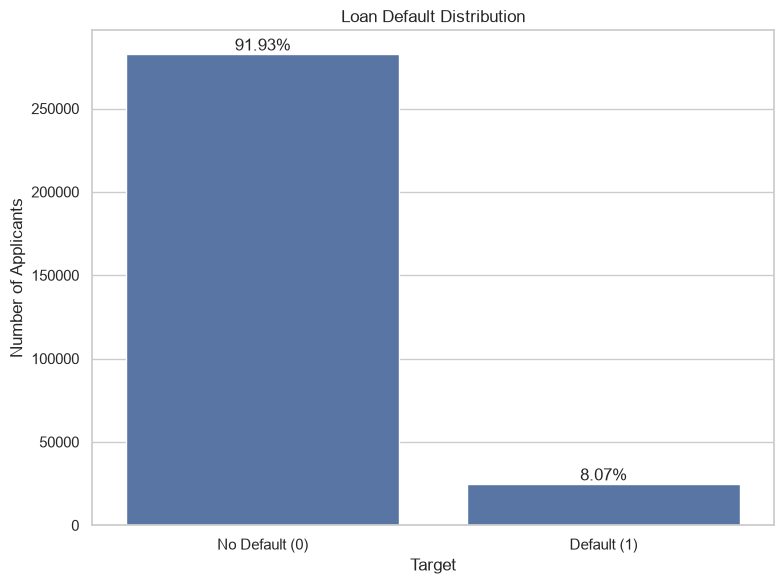

In [8]:
plt.figure(figsize=(8, 6))

ax = sns.countplot(data=df, x="TARGET")

plt.title("Loan Default Distribution")
plt.xlabel("Target")
plt.ylabel("Number of Applicants")
plt.xticks([0, 1], ["No Default (0)", "Default (1)"])

total = len(df)
for p in ax.patches:
    percentage = p.get_height() / total * 100
    ax.annotate(
        f"{percentage:.2f}%",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center", va="bottom"
    )

plt.tight_layout()
plt.savefig(CHART_DIR / "01_target_distribution.png", dpi=120)
plt.show()

Class Imbalance: at roughly 8% default rate, the dataset is imbalanced - default cases represent a significantly smaller share than non-default cases. Accuracy alone won't be an appropriate evaluation metric; ROC-AUC and PR-AUC are needed instead, along with explicit imbalance handling during training (e.g. class weighting) rather than training on raw class proportions.

## 6. Data Quality Analysis

checking missing values, duplicates, and data types here - this
directly decides cleaning/imputation strategy in the next phase.

### 6.1 Missing Value Analysis

In [9]:
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100

missing_df = pd.DataFrame({
    "Column": df.columns,
    "Missing Values": missing_values.values,
    "Missing Percentage": missing_percentage.values
})

missing_df = missing_df.sort_values("Missing Percentage", ascending=False)

missing_df.head(20)

,Column,Missing Values,Missing Percentage
48,COMMONAREA_AVG,214865,69.872297
62,COMMONAREA_MODE,214865,69.872297
76,COMMONAREA_MEDI,214865,69.872297
84,NONLIVINGAPARTMENTS_MEDI,213514,69.432963
70,NONLIVINGAPARTMENTS_MODE,213514,69.432963
56,NONLIVINGAPARTMENTS_AVG,213514,69.432963
86,FONDKAPREMONT_MODE,210295,68.386172
54,LIVINGAPARTMENTS_AVG,210199,68.354953
82,LIVINGAPARTMENTS_MEDI,210199,68.354953
68,LIVINGAPARTMENTS_MODE,210199,68.354953


### 6.2 Categorize Missing Values
Each column is grouped into a missingness tier

In [10]:
def missing_category(value):
    if value == 0:
        return "No Missing Values"
    elif value <= 10:
        return "Low Missingness (0-10%)"
    elif value <= 40:
        return "Moderate Missingness (10-40%)"
    elif value <= 60:
        return "High Missingness (40-60%)"
    else:
        return "Very High Missingness (>60%)"


missing_df["Missing Category"] = missing_df["Missing Percentage"].apply(missing_category)

missing_df.head(30)

,Column,Missing Values,Missing Percentage,Missing Category
48,COMMONAREA_AVG,214865,69.872297,Very High Missingness (>60%)
62,COMMONAREA_MODE,214865,69.872297,Very High Missingness (>60%)
76,COMMONAREA_MEDI,214865,69.872297,Very High Missingness (>60%)
84,NONLIVINGAPARTMENTS_MEDI,213514,69.432963,Very High Missingness (>60%)
70,NONLIVINGAPARTMENTS_MODE,213514,69.432963,Very High Missingness (>60%)
56,NONLIVINGAPARTMENTS_AVG,213514,69.432963,Very High Missingness (>60%)
86,FONDKAPREMONT_MODE,210295,68.386172,Very High Missingness (>60%)
54,LIVINGAPARTMENTS_AVG,210199,68.354953,Very High Missingness (>60%)
82,LIVINGAPARTMENTS_MEDI,210199,68.354953,Very High Missingness (>60%)
68,LIVINGAPARTMENTS_MODE,210199,68.354953,Very High Missingness (>60%)


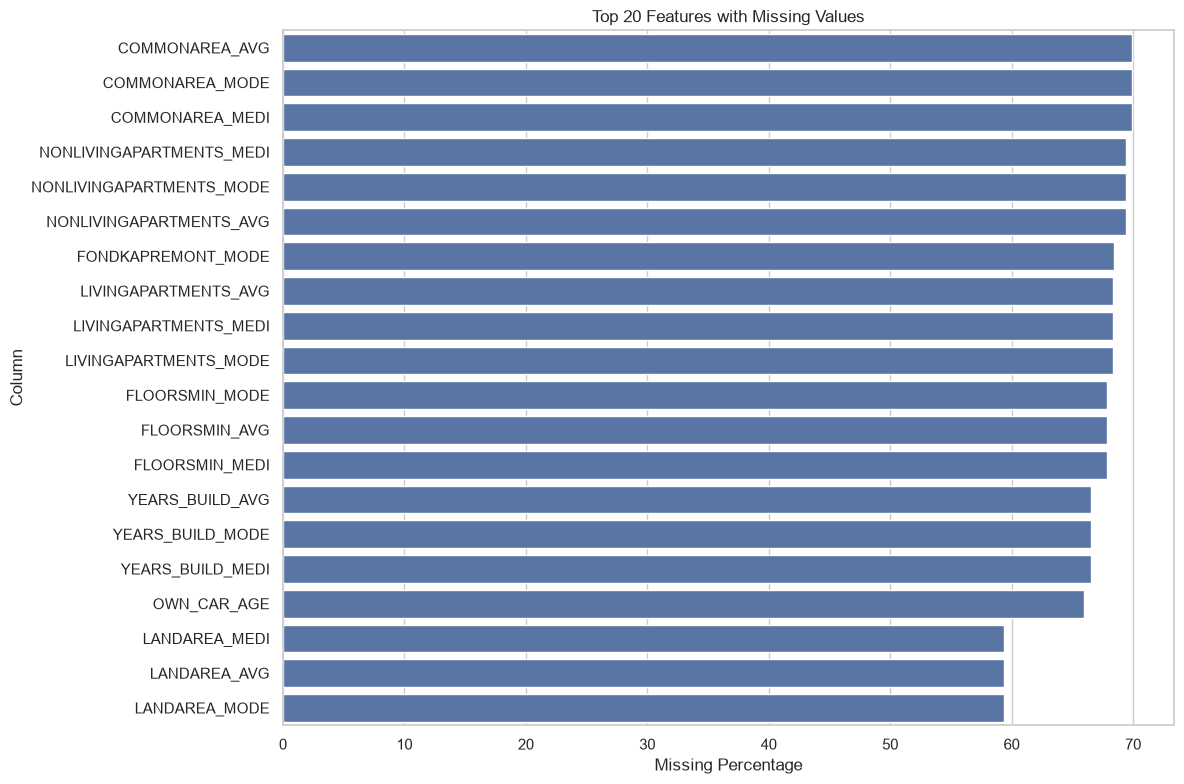

In [11]:
top_missing = missing_df[missing_df["Missing Percentage"] > 0].head(20)

plt.figure(figsize=(12, 8))
sns.barplot(data=top_missing, x="Missing Percentage", y="Column")
plt.title("Top 20 Features with Missing Values")
plt.tight_layout()
plt.savefig(CHART_DIR / "02_missing_values.png", dpi=120)
plt.show()

### 6.3 Duplicate Analysis

In [12]:
duplicates = df.duplicated().sum()
print("Number of Duplicate Rows:", duplicates)

Number of Duplicate Rows: 0


### 6.4 Missing Value Summary

In [13]:
missing_summary = (
    missing_df
    .groupby("Missing Category")
    .size()
    .reset_index(name="Number of Columns")
)

missing_summary

,Missing Category,Number of Columns
0,High Missingness (40-60%),32
1,Low Missingness (0-10%),10
2,Moderate Missingness (10-40%),8
3,No Missing Values,55
4,Very High Missingness (>60%),17


No duplicate rows were found, so no deduplication step is needed. 17 fall in the "Very High Missingness" tier (>60%) - almost entirely apartment/building detail fields (e.g. COMMONAREA_AVG at 69.87%) that were likely collected the same way three
times (avg/mode/medi), plus OWN_CAR_AGE (65.99%, structurally missing for non-car-owners). 32 columns fall in "High Missingness" (40-60%) and
will need individual review before deciding drop vs. impute. The remaining 18 columns (10 "Low" + 8 "Moderate") are reasonable to impute
directly - median for numeric, a dedicated "Unknown" category for categorical.

## 7. Feature Understanding & Categorization

Rather than reviewing 122+ columns in no particular order, they are grouped here into business-meaningful categories.

In [18]:
feature_categories = {
    "Demographics": [
        "CODE_GENDER", "DAYS_BIRTH", "CNT_CHILDREN",
        "NAME_FAMILY_STATUS", "NAME_EDUCATION_TYPE"
    ],
    "Financial": [
        "AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY", "AMT_GOODS_PRICE"
    ],
    "Employment": [
    "NAME_INCOME_TYPE", "OCCUPATION_TYPE", "DAYS_EMPLOYED"
],
    "Family": [
        "CNT_FAM_MEMBERS", "NAME_FAMILY_STATUS", "CNT_CHILDREN"
    ],
    "Assets": [
        "FLAG_OWN_CAR", "FLAG_OWN_REALTY"
    ],
    "Housing": [
        "NAME_HOUSING_TYPE", "REGION_POPULATION_RELATIVE"
    ],
    "Credit Bureau": [
        "AMT_REQ_CREDIT_BUREAU_HOUR", "AMT_REQ_CREDIT_BUREAU_DAY",
        "AMT_REQ_CREDIT_BUREAU_WEEK", "AMT_REQ_CREDIT_BUREAU_MON",
        "AMT_REQ_CREDIT_BUREAU_QRT", "AMT_REQ_CREDIT_BUREAU_YEAR"
    ],
    "Other": [
        "FLAG_MOBIL", "FLAG_EMAIL", "WEEKDAY_APPR_PROCESS_START"
    ],
}

for category, columns in feature_categories.items():
    print(f"\n{category}")
    for column in columns:
        if column in df.columns:
            print(" -", column)


Demographics
 - CODE_GENDER
 - DAYS_BIRTH
 - CNT_CHILDREN
 - NAME_FAMILY_STATUS
 - NAME_EDUCATION_TYPE

Financial
 - AMT_INCOME_TOTAL
 - AMT_CREDIT
 - AMT_ANNUITY
 - AMT_GOODS_PRICE

Employment
 - NAME_INCOME_TYPE
 - OCCUPATION_TYPE
 - DAYS_EMPLOYED

Family
 - CNT_FAM_MEMBERS
 - NAME_FAMILY_STATUS
 - CNT_CHILDREN

Assets
 - FLAG_OWN_CAR
 - FLAG_OWN_REALTY

Housing
 - NAME_HOUSING_TYPE
 - REGION_POPULATION_RELATIVE

Credit Bureau
 - AMT_REQ_CREDIT_BUREAU_HOUR
 - AMT_REQ_CREDIT_BUREAU_DAY
 - AMT_REQ_CREDIT_BUREAU_WEEK
 - AMT_REQ_CREDIT_BUREAU_MON
 - AMT_REQ_CREDIT_BUREAU_QRT
 - AMT_REQ_CREDIT_BUREAU_YEAR

Other
 - FLAG_MOBIL
 - FLAG_EMAIL
 - WEEKDAY_APPR_PROCESS_START


## 8. Data Anomaly Analysis

DAYS_EMPLOYED contains a known placeholder value that needs flagging
before it reaches the model as a fake numeric outlier.

In [19]:
df["DAYS_EMPLOYED"].describe()

count    307511.000000
mean      63815.045904
std      141275.766519
min      -17912.000000
25%       -2760.000000
50%       -1213.000000
75%        -289.000000
max      365243.000000
Name: DAYS_EMPLOYED, dtype: float64

In [20]:
df["DAYS_EMPLOYED"].value_counts().head()

DAYS_EMPLOYED
 365243    55374
-200         156
-224         152
-199         151
-230         151
Name: count, dtype: int64

In [21]:
pct_anomaly = (df["DAYS_EMPLOYED"] == 365243).sum() / len(df) * 100
print(f"{pct_anomaly:.2f}%")

18.01%


In [23]:
df[df["DAYS_EMPLOYED"] == 365243]["NAME_INCOME_TYPE"].value_counts()

NAME_INCOME_TYPE
Pensioner     55352
Unemployed       22
Name: count, dtype: int64

## 9. Feature Engineering for EDA

Creating business-meaningful features here to make the rest of the
analysis more interpretable - these are candidates to be formalized in a separate feature engineering pipeline

### 9.1 Age
The dataset stores age as negative days, converted here to positive years.

In [24]:
df["AGE_YEARS"] = df["DAYS_BIRTH"].abs() / 365

### 9.2 Employment Years
The 365243 anomaly is replaced with NaN first, then converted to years

In [25]:
df["DAYS_EMPLOYED_CLEAN"] = df["DAYS_EMPLOYED"].replace(365243, np.nan)
df["EMPLOYMENT_YEARS"] = df["DAYS_EMPLOYED_CLEAN"].abs() / 365

### 9.3 Loan-to-Income Ratio
`AMT_CREDIT / AMT_INCOME_TOTAL` - how large is the requested loan
relative to the applicant's income. A higher ratio may indicate the
applicant is requesting a loan that's large relative to what they earn.

In [26]:
df["LOAN_TO_INCOME_RATIO"] = df["AMT_CREDIT"] / df["AMT_INCOME_TOTAL"]

### 9.4 Annuity-to-Income Ratio
`AMT_ANNUITY / AMT_INCOME_TOTAL` - regular payment relative to income.
This approximates the applicant's repayment burden.

In [27]:
df["ANNUITY_TO_INCOME_RATIO"] = df["AMT_ANNUITY"] / df["AMT_INCOME_TOTAL"]

## 10. Univariate Analysis

Studying individual features on their own, before comparing anything
against the target.

### 10.1 Age Distribution

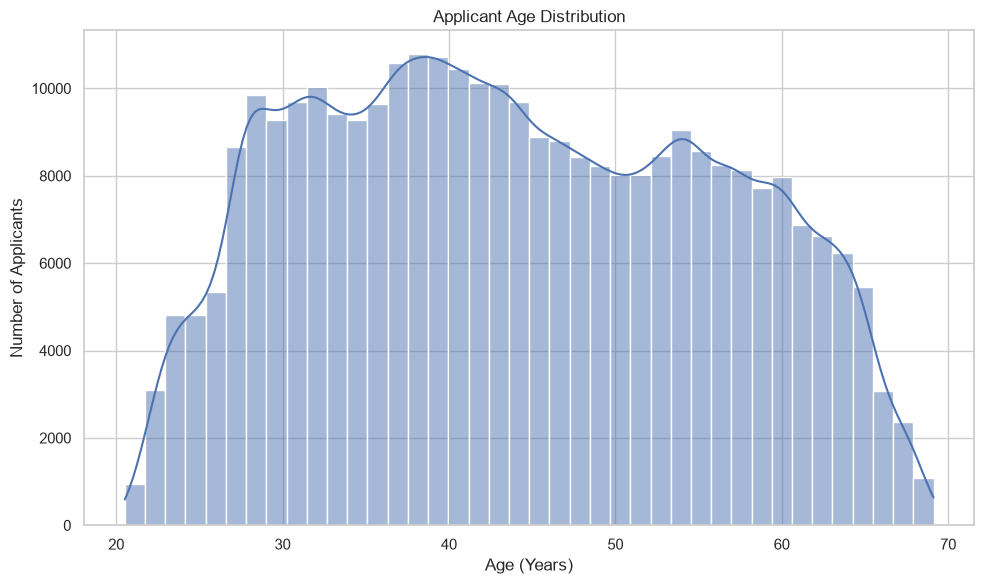

In [28]:
plt.figure(figsize=(10, 6))
sns.histplot(df["AGE_YEARS"], bins=40, kde=True)
plt.title("Applicant Age Distribution")
plt.xlabel("Age (Years)")
plt.ylabel("Number of Applicants")
plt.tight_layout()
plt.savefig(CHART_DIR / "03_age_distribution.png", dpi=120)
plt.show()

### 10.2 Income Distribution
Income contains extreme values, so log transform just for
visualization - this doesn't change the underlying data, only how it's
plotted.

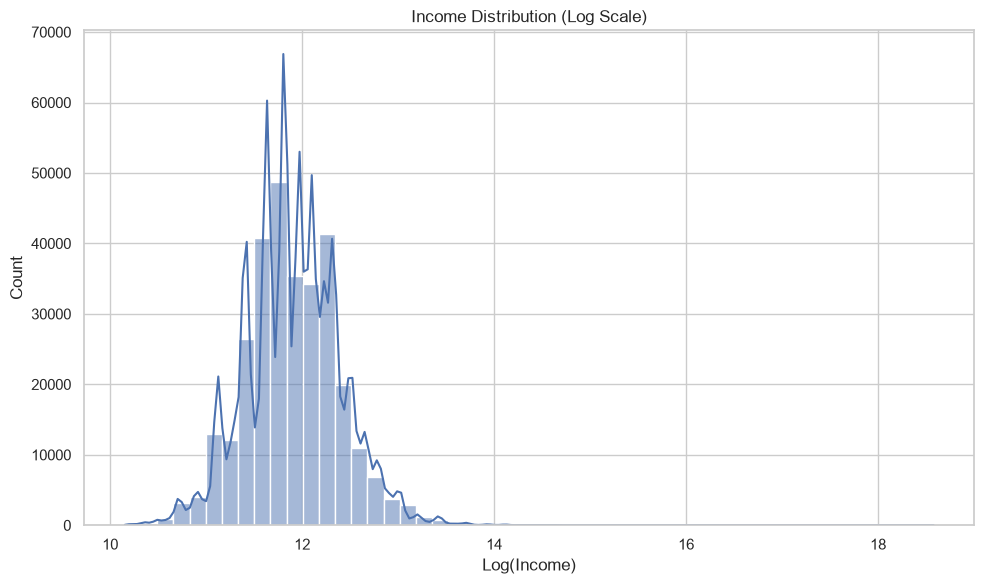

In [29]:
plt.figure(figsize=(10, 6))
sns.histplot(np.log1p(df["AMT_INCOME_TOTAL"]), bins=50, kde=True)
plt.title("Income Distribution (Log Scale)")
plt.xlabel("Log(Income)")
plt.tight_layout()
plt.savefig(CHART_DIR / "04_income_distribution.png", dpi=120)
plt.show()

### 10.3 Loan Amount Distribution

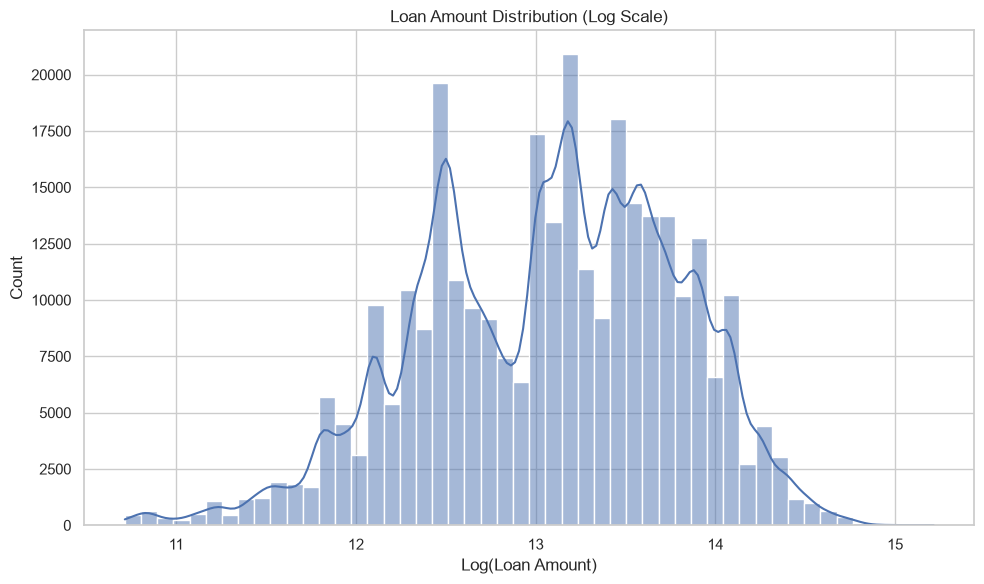

In [30]:
plt.figure(figsize=(10, 6))
sns.histplot(np.log1p(df["AMT_CREDIT"]), bins=50, kde=True)
plt.title("Loan Amount Distribution (Log Scale)")
plt.xlabel("Log(Loan Amount)")
plt.tight_layout()
plt.savefig(CHART_DIR / "05_loan_amount_distribution.png", dpi=120)
plt.show()

### 10.4 Employment Duration Distribution

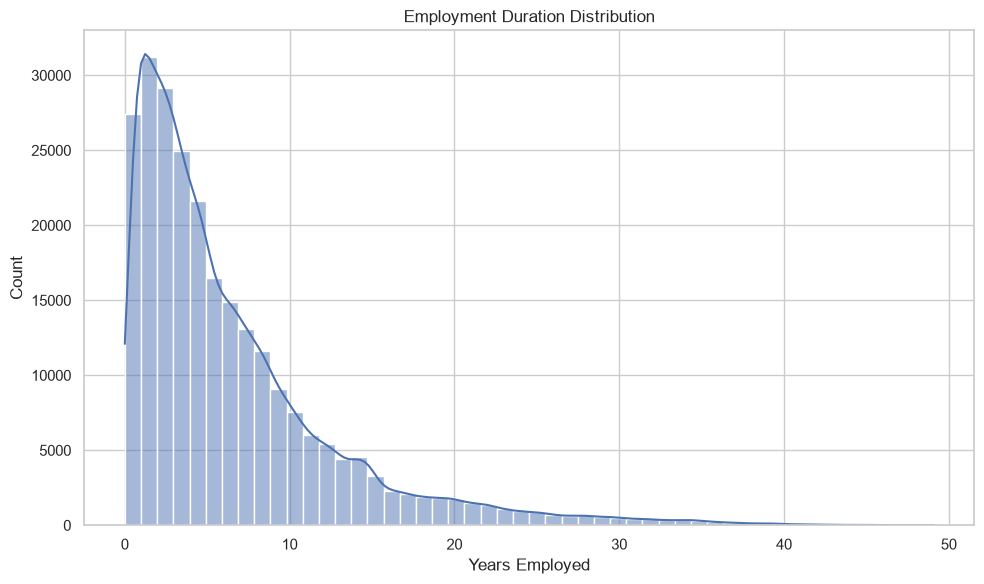

In [31]:
plt.figure(figsize=(10, 6))
sns.histplot(df["EMPLOYMENT_YEARS"].dropna(), bins=50, kde=True)
plt.title("Employment Duration Distribution")
plt.xlabel("Years Employed")
plt.tight_layout()
plt.savefig(CHART_DIR / "06_employment_distribution.png", dpi=120)
plt.show()

## 11. Outlier Analysis

Visualizing income, loan amount, and annuity for extreme values.

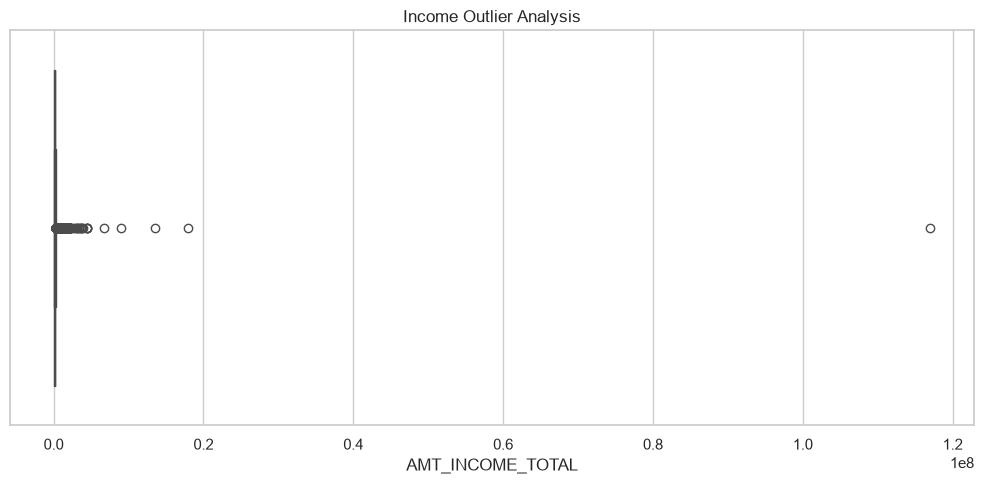

In [32]:
plt.figure(figsize=(10, 5))
sns.boxplot(x=df["AMT_INCOME_TOTAL"])
plt.title("Income Outlier Analysis")
plt.tight_layout()
plt.savefig(CHART_DIR / "07_income_outliers.png", dpi=120)
plt.show()

In [35]:
print(df["AMT_INCOME_TOTAL"].max())
df[df["AMT_INCOME_TOTAL"] > 50000000][["SK_ID_CURR", "AMT_INCOME_TOTAL", "NAME_INCOME_TYPE", "TARGET"]]

117000000.0


,SK_ID_CURR,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,TARGET
12840,114967,117000000.0,Working,1


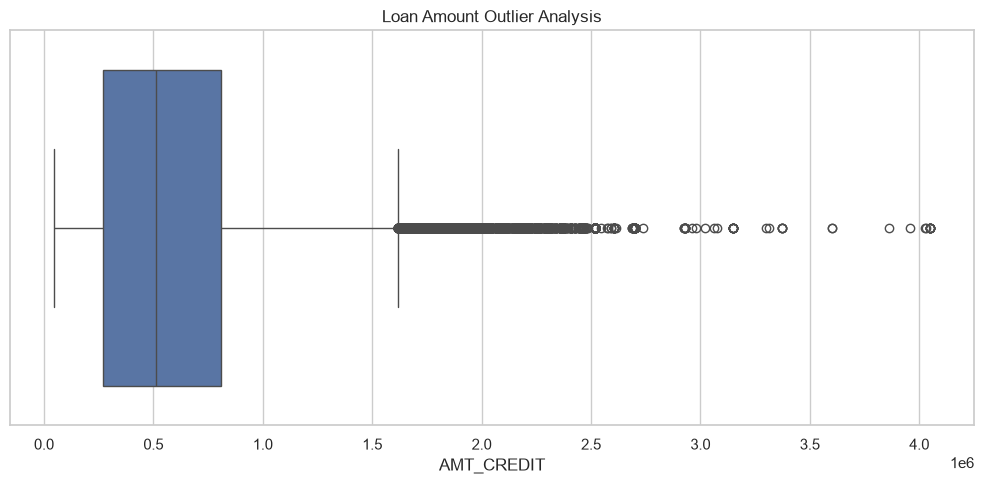

In [33]:
plt.figure(figsize=(10, 5))
sns.boxplot(x=df["AMT_CREDIT"])
plt.title("Loan Amount Outlier Analysis")
plt.tight_layout()
plt.savefig(CHART_DIR / "08_loan_outliers.png", dpi=120)
plt.show()

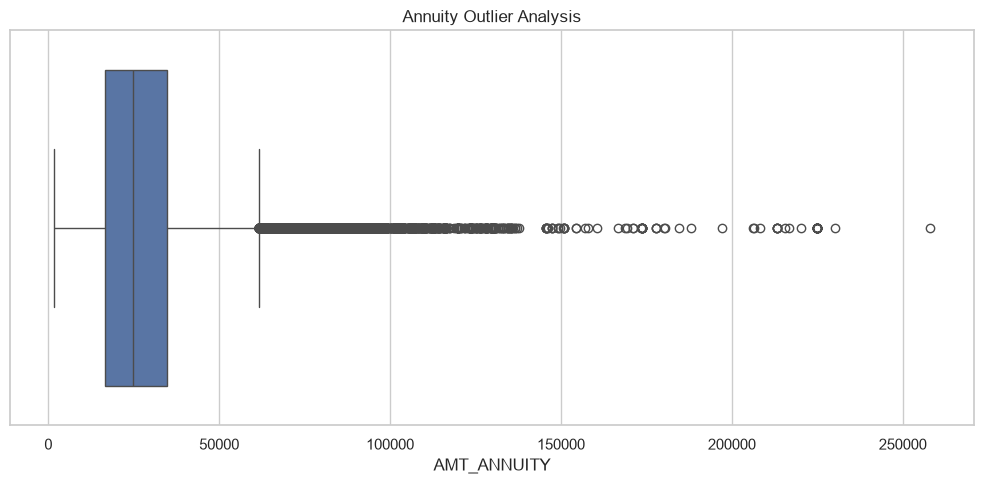

In [34]:
plt.figure(figsize=(10, 5))
sns.boxplot(x=df["AMT_ANNUITY"])
plt.title("Annuity Outlier Analysis")
plt.tight_layout()
plt.savefig(CHART_DIR / "09_annuity_outliers.png", dpi=120)
plt.show()

## 12. Categorical Feature Distribution

Understanding the population itself before comparing anything against
default - e.g. what does the applicant base actually look like.

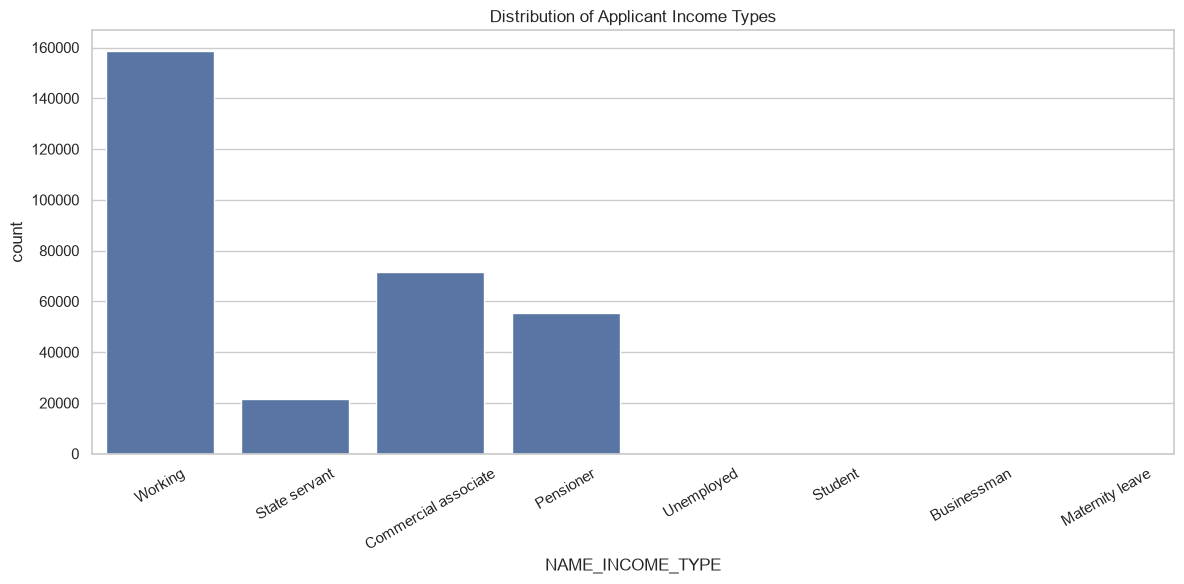

In [36]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x="NAME_INCOME_TYPE")
plt.xticks(rotation=30)
plt.title("Distribution of Applicant Income Types")
plt.tight_layout()
plt.savefig(CHART_DIR / "10_income_type_distribution.png", dpi=120)
plt.show()

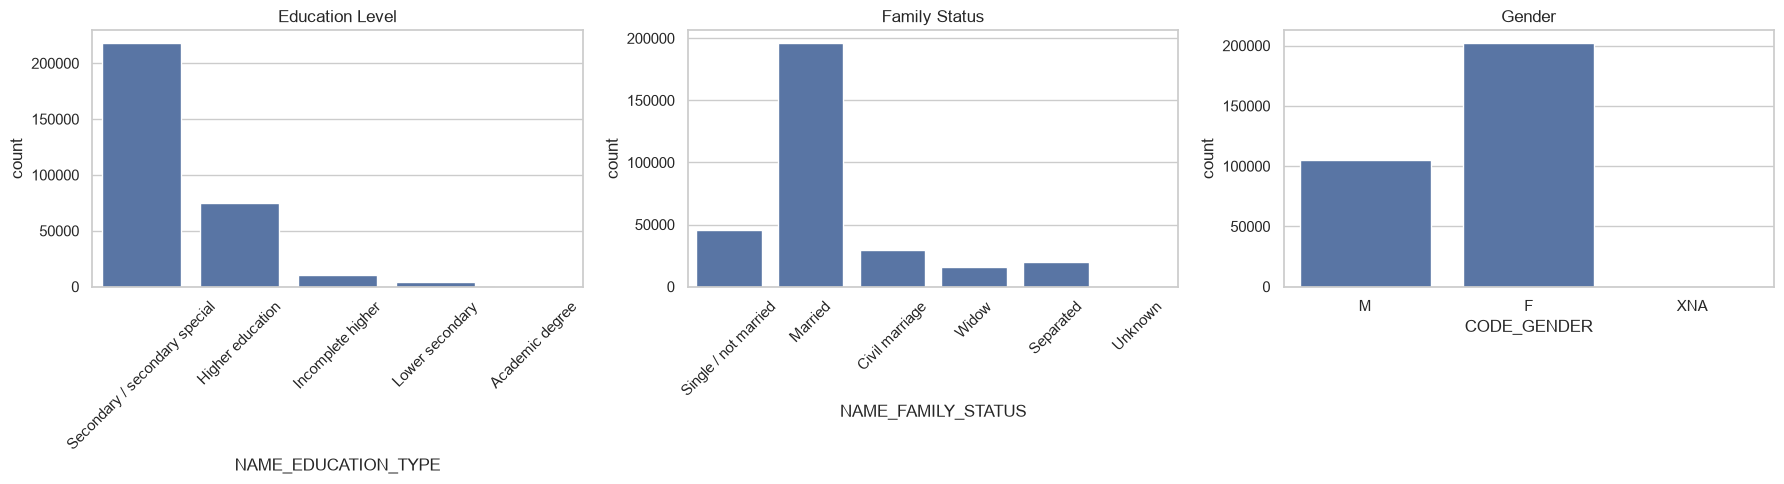

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(data=df, x="NAME_EDUCATION_TYPE", ax=axes[0])
axes[0].set_title("Education Level")
axes[0].tick_params(axis="x", rotation=45)

sns.countplot(data=df, x="NAME_FAMILY_STATUS", ax=axes[1])
axes[1].set_title("Family Status")
axes[1].tick_params(axis="x", rotation=45)

sns.countplot(data=df, x="CODE_GENDER", ax=axes[2])
axes[2].set_title("Gender")

plt.tight_layout()
plt.savefig(CHART_DIR / "11_categorical_distributions.png", dpi=120)
plt.show()

In [38]:
df["CODE_GENDER"].value_counts()

CODE_GENDER
F      202448
M      105059
XNA         4
Name: count, dtype: int64

## 13. Bivariate Risk Analysis

The most important section - comparing features against `TARGET` to see
which ones actually relate to default.

### 13.1 Default Rate by Age

AGE_GROUP
Below 25    12.303643
25-35       10.673287
35-45        8.404727
45-55        7.057951
55-65        5.414549
65+          3.727015
Name: TARGET, dtype: float64


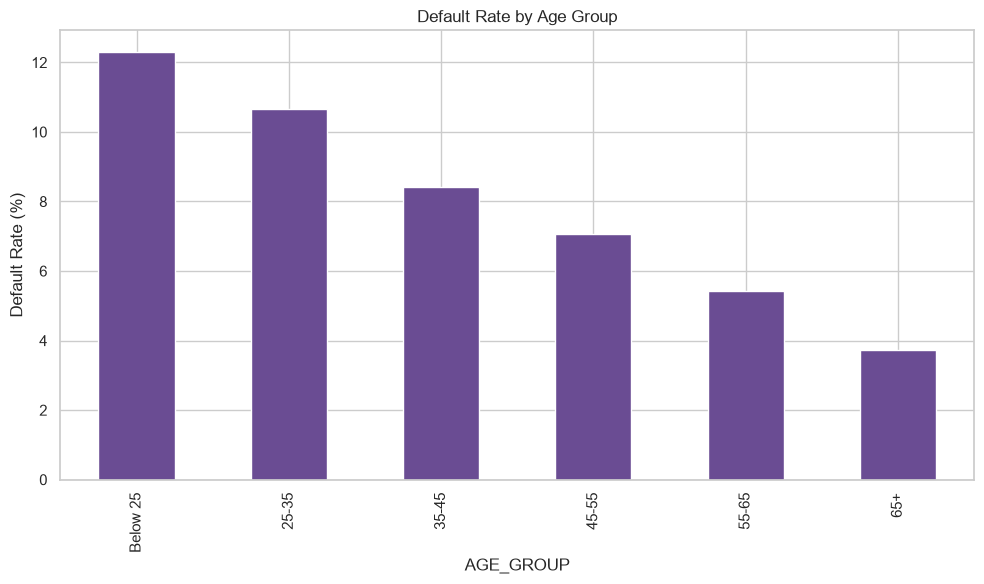

In [39]:
df["AGE_GROUP"] = pd.cut(
    df["AGE_YEARS"],
    bins=[0, 25, 35, 45, 55, 65, 100],
    labels=["Below 25", "25-35", "35-45", "45-55", "55-65", "65+"]
)

age_default = df.groupby("AGE_GROUP", observed=True)["TARGET"].mean() * 100
print(age_default)

age_default.plot(kind="bar", figsize=(10, 6), color="#6A4C93")
plt.title("Default Rate by Age Group")
plt.ylabel("Default Rate (%)")
plt.tight_layout()
plt.savefig(CHART_DIR / "12_default_by_age.png", dpi=120)
plt.show()

### 13.2 Default Rate by Income

INCOME_GROUP
(25649.999, 99000.0]       8.206248
(99000.0, 135000.0]        8.588320
(135000.0, 162000.0]       8.684738
(162000.0, 225000.0]       8.056891
(225000.0, 117000000.0]    6.519801
Name: TARGET, dtype: float64


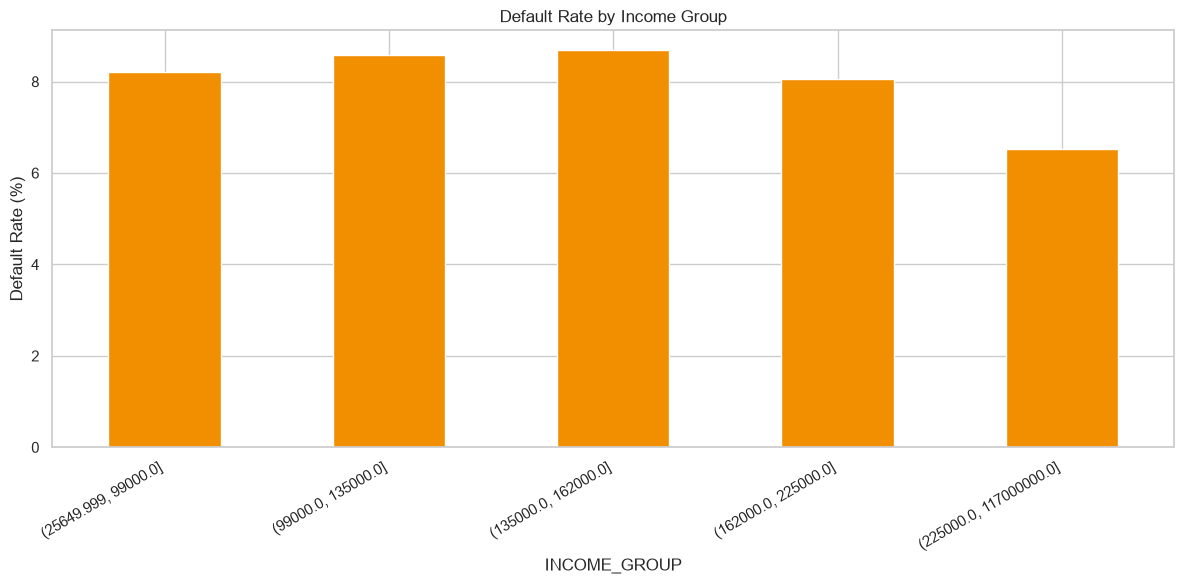

In [40]:
df["INCOME_GROUP"] = pd.qcut(df["AMT_INCOME_TOTAL"], q=5, duplicates="drop")

income_default = df.groupby("INCOME_GROUP", observed=True)["TARGET"].mean() * 100
print(income_default)

income_default.plot(kind="bar", figsize=(12, 6), color="#F18F01")
plt.title("Default Rate by Income Group")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(CHART_DIR / "13_default_by_income.png", dpi=120)
plt.show()

### 13.3 Default Rate by Loan Amount

LOAN_GROUP
(44999.999, 254700.0]     7.237582
(254700.0, 432000.0]      9.172433
(432000.0, 604152.0]     10.054913
(604152.0, 900000.0]      7.854867
(900000.0, 4050000.0]     6.075163
Name: TARGET, dtype: float64


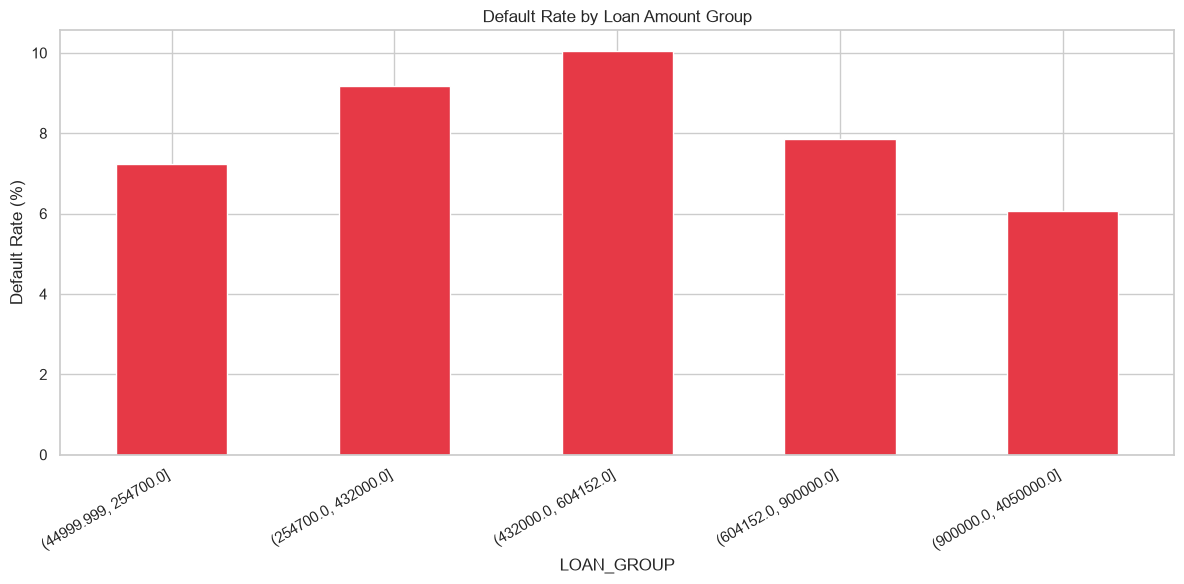

In [41]:
df["LOAN_GROUP"] = pd.qcut(df["AMT_CREDIT"], q=5, duplicates="drop")

loan_default = df.groupby("LOAN_GROUP", observed=True)["TARGET"].mean() * 100
print(loan_default)

loan_default.plot(kind="bar", figsize=(12, 6), color="#E63946")
plt.title("Default Rate by Loan Amount Group")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(CHART_DIR / "14_default_by_loan_amount.png", dpi=120)
plt.show()

### 13.4 Default Rate by Education

In [42]:
education_default = df.groupby("NAME_EDUCATION_TYPE")["TARGET"].mean() * 100
education_default = education_default.sort_values(ascending=False)
print(education_default)

NAME_EDUCATION_TYPE
Lower secondary                  10.927673
Secondary / secondary special     8.939929
Incomplete higher                 8.484966
Higher education                  5.355115
Academic degree                   1.829268
Name: TARGET, dtype: float64


### 13.5 Default Rate by Income Type

In [43]:
income_type_default = df.groupby("NAME_INCOME_TYPE")["TARGET"].mean() * 100
income_type_default = income_type_default.sort_values(ascending=False)
print(income_type_default)

NAME_INCOME_TYPE
Maternity leave         40.000000
Unemployed              36.363636
Working                  9.588472
Commercial associate     7.484257
State servant            5.754965
Pensioner                5.386366
Businessman              0.000000
Student                  0.000000
Name: TARGET, dtype: float64


### 13.6 Default Rate by Employment Duration

EMPLOYMENT_GROUP
< 1 Year       10.971339
1-3 Years      11.073334
3-5 Years       9.674115
5-10 Years      7.371439
10-20 Years     5.513308
20+ Years       4.189232
Name: TARGET, dtype: float64


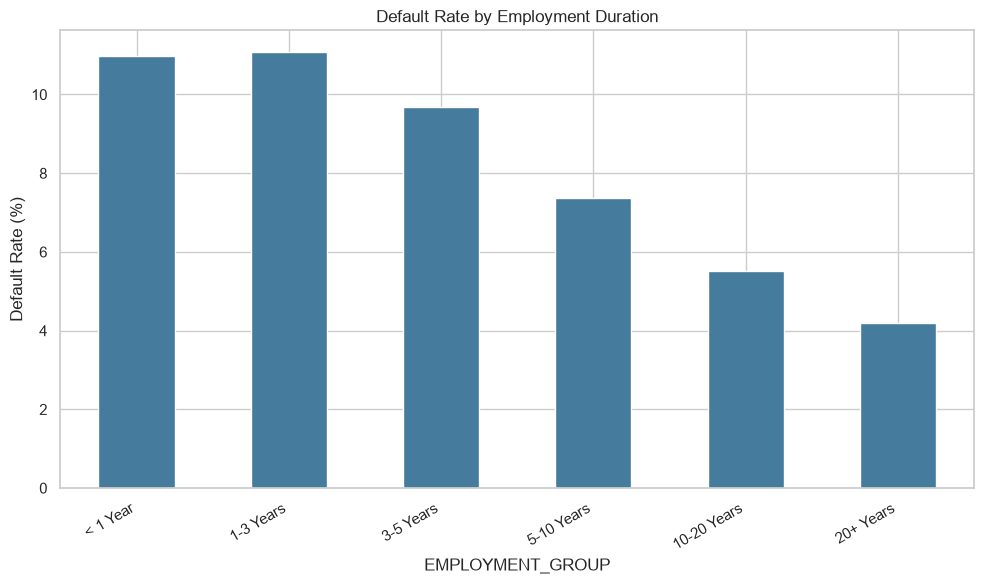

In [44]:
df["EMPLOYMENT_GROUP"] = pd.cut(
    df["EMPLOYMENT_YEARS"],
    bins=[-1, 1, 3, 5, 10, 20, 100],
    labels=["< 1 Year", "1-3 Years", "3-5 Years", "5-10 Years", "10-20 Years", "20+ Years"]
)

employment_default = df.groupby("EMPLOYMENT_GROUP", observed=True)["TARGET"].mean() * 100
print(employment_default)

employment_default.plot(kind="bar", figsize=(10, 6), color="#457B9D")
plt.title("Default Rate by Employment Duration")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(CHART_DIR / "15_default_by_employment.png", dpi=120)
plt.show()

### 13.7 Default Rate by Gender

In [45]:
gender_default = df.groupby("CODE_GENDER")["TARGET"].mean() * 100
print(gender_default)

CODE_GENDER
F       6.999328
M      10.141920
XNA     0.000000
Name: TARGET, dtype: float64


### 13.8 Default Rate by Family Status

In [46]:
family_default = df.groupby("NAME_FAMILY_STATUS")["TARGET"].mean().sort_values(ascending=False) * 100
print(family_default)

NAME_FAMILY_STATUS
Civil marriage          9.944584
Single / not married    9.807675
Separated               8.194234
Married                 7.559868
Widow                   5.824217
Unknown                 0.000000
Name: TARGET, dtype: float64


## 14. Financial Risk Analysis

### Default Rate by Loan-to-Income Ratio

RATIO_GROUP
(0.00381, 1.818]    7.335186
(1.818, 2.764]      8.567201
(2.764, 3.906]      8.925259
(3.906, 5.769]      8.283879
(5.769, 84.737]     7.253776
Name: TARGET, dtype: float64


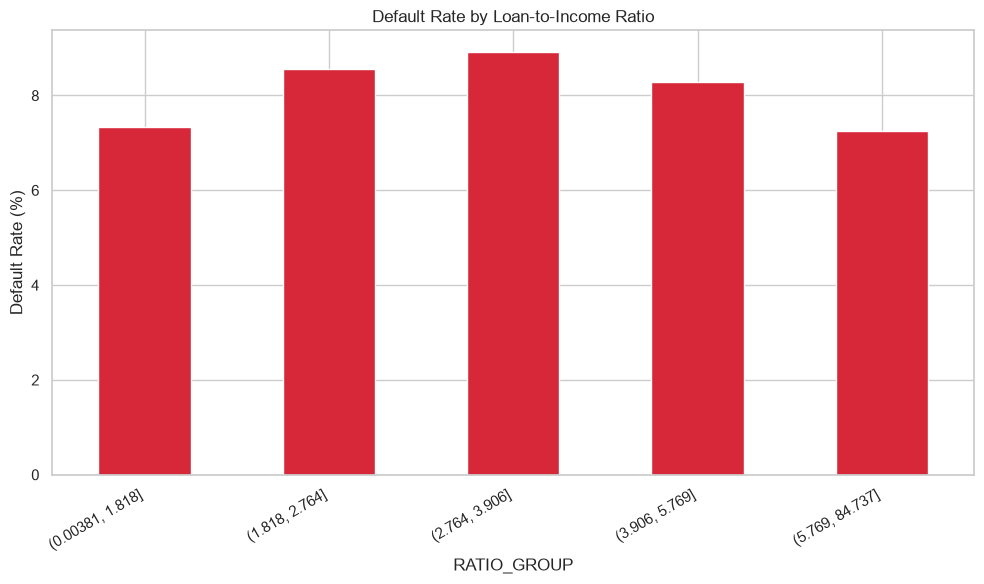

In [47]:
ratio_df = df.dropna(subset=["LOAN_TO_INCOME_RATIO"]).copy()
ratio_df["RATIO_GROUP"] = pd.qcut(ratio_df["LOAN_TO_INCOME_RATIO"], q=5, duplicates="drop")

ratio_default = ratio_df.groupby("RATIO_GROUP", observed=True)["TARGET"].mean() * 100
print(ratio_default)

ratio_default.plot(kind="bar", figsize=(10, 6), color="#D62839")
plt.title("Default Rate by Loan-to-Income Ratio")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(CHART_DIR / "16_default_by_loan_to_income.png", dpi=120)
plt.show()

### Default Rate by Annuity-to-Income Ratio

ANNUITY_RATIO_GROUP
(-0.000776, 0.104]    7.196748
(0.104, 0.144]        7.831629
(0.144, 0.186]        8.125996
(0.186, 0.247]        8.696076
(0.247, 1.876]        8.515518
Name: TARGET, dtype: float64


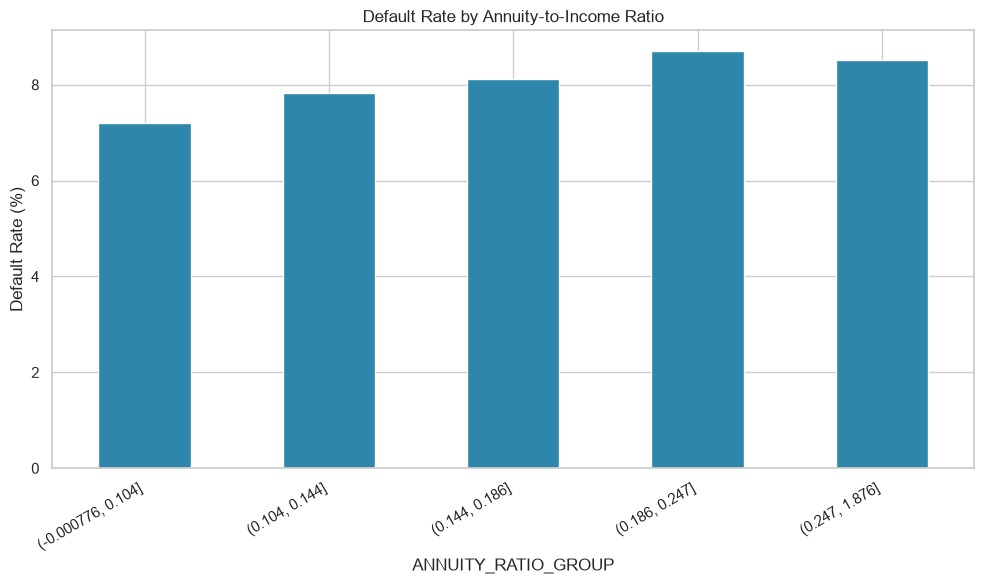

In [48]:
annuity_df = df.dropna(subset=["ANNUITY_TO_INCOME_RATIO"]).copy()
annuity_df["ANNUITY_RATIO_GROUP"] = pd.qcut(
    annuity_df["ANNUITY_TO_INCOME_RATIO"], q=5, duplicates="drop"
)

annuity_default = annuity_df.groupby("ANNUITY_RATIO_GROUP", observed=True)["TARGET"].mean() * 100
print(annuity_default)

annuity_default.plot(kind="bar", figsize=(10, 6), color="#2E86AB")
plt.title("Default Rate by Annuity-to-Income Ratio")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(CHART_DIR / "17_default_by_annuity_to_income.png", dpi=120)
plt.show()

## 15. Asset Analysis

### Car Ownership

In [49]:
car_default = df.groupby("FLAG_OWN_CAR")["TARGET"].mean() * 100
print(car_default)

FLAG_OWN_CAR
N    8.500227
Y    7.243730
Name: TARGET, dtype: float64


### Property Ownership

In [50]:
property_default = df.groupby("FLAG_OWN_REALTY")["TARGET"].mean() * 100
print(property_default)

FLAG_OWN_REALTY
N    8.324929
Y    7.961577
Name: TARGET, dtype: float64


## 16. Correlation Analysis

In [51]:
numeric_df = df.select_dtypes(include=["int64", "float64"])

target_correlation = numeric_df.corr()["TARGET"].sort_values()
print(target_correlation)

EXT_SOURCE_3                  -0.178919
EXT_SOURCE_2                  -0.160472
EXT_SOURCE_1                  -0.155317
AGE_YEARS                     -0.078239
EMPLOYMENT_YEARS              -0.074958
                                 ...   
REGION_RATING_CLIENT           0.058899
REGION_RATING_CLIENT_W_CITY    0.060893
DAYS_EMPLOYED_CLEAN            0.074958
DAYS_BIRTH                     0.078239
TARGET                         1.000000
Name: TARGET, Length: 111, dtype: float64


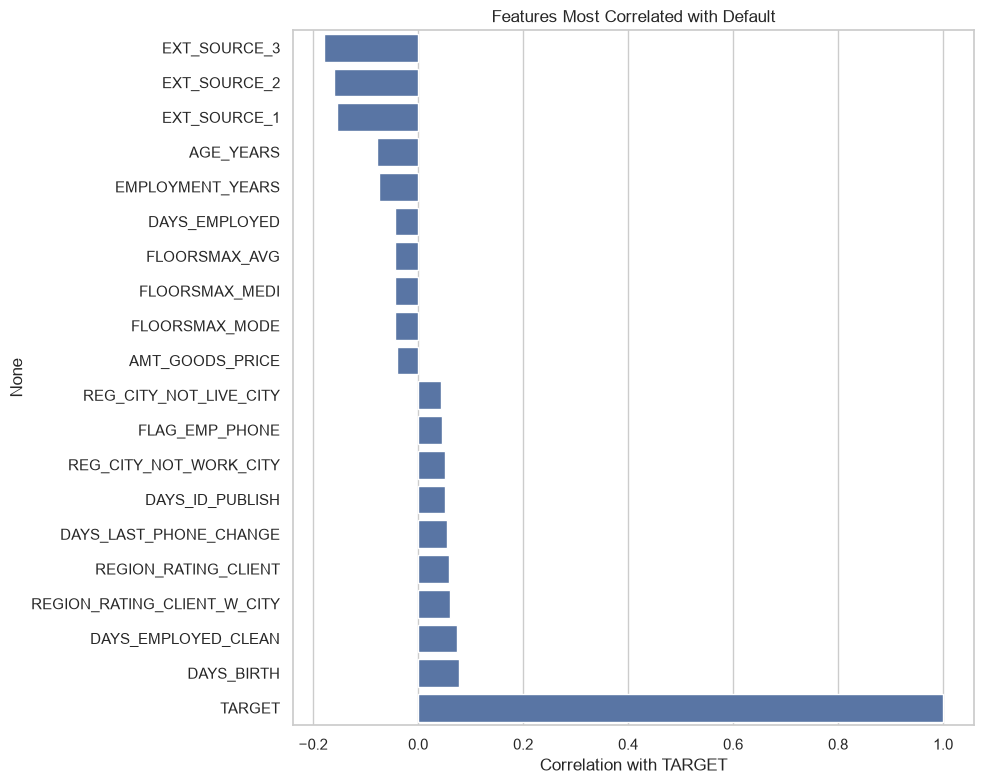

In [52]:
top_features = pd.concat([
    target_correlation.head(10),
    target_correlation.tail(10)
]).drop_duplicates()

plt.figure(figsize=(10, 8))
sns.barplot(x=top_features.values, y=top_features.index)
plt.title("Features Most Correlated with Default")
plt.xlabel("Correlation with TARGET")
plt.tight_layout()
plt.savefig(CHART_DIR / "18_correlation_analysis.png", dpi=120)
plt.show()

## 17. Feature Availability Analysis

**Available at loan application time:** age, income, employment,
education, requested loan amount, housing, assets.

**Available from credit history:** credit bureau information, previous
applications, installment history, credit card history.

## 18. EDA Key Findings

1. Default rate is 8.07% overall - imbalanced enough that accuracy is a useless metric here (predicting "no default" every time scores ~92%
while catching nothing). ROC-AUC/PR-AUC needed instead.

2. Missing data: 55 of 122 columns are complete. The 17 columns above 60% missing are mostly redundant building-detail fields (avg/mode/medi
versions of the same thing) - dropping those. OWN_CAR_AGE's 66% missing is structural (non-car-owners), so that gets imputed as 0, not median.
No duplicate rows.

3. Age is the cleanest signal in the dataset - default rate drops from 12.3% (under 25) to 3.7% (65+), almost linearly. Employment duration
tells a similar story: 11% in the first 3 years, down to 4.2% at 20+ years.

4. Income is flat (~8.1-8.7%) except at the very top - only the 225K+ quintile drops meaningfully, to 6.5%. The engineered ratios
split differently too: annuity-to-income rises fairly consistently (7.2% -> 8.7%), but loan-to-income is non-monotonic - it peaks mid-range
at 8.9% and actually falls back to 7.3% at the highest band, so it's not a simple "bigger loan = riskier" story.

5. Two data quality issues: DAYS_EMPLOYED's 365243 value (18% of rows) is Home Credit's placeholder for "not employed" - 99.96%
of those rows are Pensioners. And one applicant (SK_ID_CURR 114967) reports 117 million in income while "Working" - an entry error.
CODE_GENDER also has 4 rows with "XNA" instead of M/F - negligible, will just drop those rows.

Strongest overall predictors: EXT_SOURCE_1/2/3, followed by age and employment duration. Income and loan-to-income ratio matter less than expected on their own.

## 19. Business Implications

**Financial Risk:** annuity-to-income ratio is a solid repayment-burden
indicator and worth a business rule. Loan-to-income ratio is less
reliable on its own (non-monotonic) - better left to the model than
turned into a simple rule.

**Customer Segmentation:** age and employment duration are the strongest,
cleanest segments for explaining risk to a non-technical reviewer - both
show steady, near-linear default patterns. Income is a weaker segment
except at the very top end.

**Data Quality:** the DAYS_EMPLOYED anomaly, heavily-missing building
columns, and the single income outlier all need handling in
preprocessing, or they'll quietly distort what the model learns.

## 20. Credit History & Repayment Behaviour

Analysis so far has used application_train.csv alone. Credit history and repayment behaviour - both explicitly required - live in three tables that connect to application_train via a join: bureau.csv (credit history at other lenders), previous_application.csv (past applications with Home Credit), and installments_payments.csv (actual repayment history).

In [53]:
import sys
sys.path.append(os.path.join(os.getcwd(), ".."))
from src.data.loader import load_all_tables

tables = load_all_tables(data_dir="../data")

Loaded app_train: (307511, 122)
Loaded app_test: (48744, 121)
Loaded bureau: (1716428, 17)
Loaded bureau_balance: (27299925, 3)
Loaded previous_application: (1670214, 37)
Loaded pos_cash: (10001358, 8)
Loaded installments: (13605401, 8)
Loaded credit_card: (3840312, 23)


### 20.1 Credit History - bureau.csv
The applicant's credit history at *other* lenders, not just Home Credit.

In [54]:
bureau = tables.get("bureau")
if bureau is not None:
    print(f"bureau.csv: {bureau.shape[0]:,} records across "
          f"{bureau['SK_ID_CURR'].nunique():,} unique applicants")
    print("\nCredit status breakdown:")
    print(bureau["CREDIT_ACTIVE"].value_counts())

    bureau_count = bureau.groupby("SK_ID_CURR").size().rename("bureau_credit_count")
    df_bureau = df.merge(bureau_count, on="SK_ID_CURR", how="left")
    df_bureau["bureau_credit_count"] = df_bureau["bureau_credit_count"].fillna(0)
    df_bureau["has_bureau_history"] = df_bureau["bureau_credit_count"] > 0

    rate = df_bureau.groupby("has_bureau_history")["TARGET"].mean() * 100
    print("\nDefault rate by presence of external bureau history:")
    print(rate)
else:
    print("bureau.csv not found in data/ - skipping.")

bureau.csv: 1,716,428 records across 305,811 unique applicants

Credit status breakdown:
CREDIT_ACTIVE
Closed      1079273
Active       630607
Sold           6527
Bad debt         21
Name: count, dtype: int64

Default rate by presence of external bureau history:
has_bureau_history
False    10.124943
True      7.730055
Name: TARGET, dtype: float64


### 20.2 Previous Applications - previous_application.csv
The applicant's past loan applications with Home Credit itself.

Default rate by prior refusal history:
has_prior_refusal
False     6.984466
True     10.321654
Name: TARGET, dtype: float64


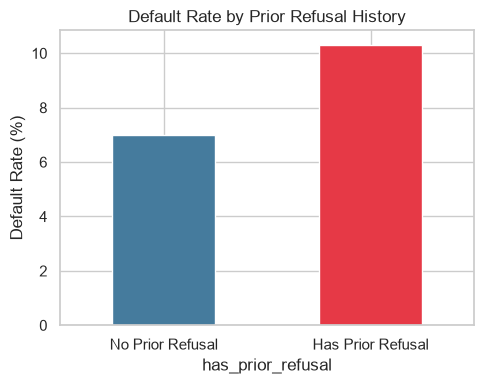

In [55]:
prev = tables.get("previous_application")
if prev is not None:
    refused = prev[prev["NAME_CONTRACT_STATUS"] == "Refused"]
    refusal_counts = refused.groupby("SK_ID_CURR").size().rename("refusal_count")

    df_prev = df.merge(refusal_counts, on="SK_ID_CURR", how="left")
    df_prev["refusal_count"] = df_prev["refusal_count"].fillna(0)
    df_prev["has_prior_refusal"] = df_prev["refusal_count"] > 0

    rate = df_prev.groupby("has_prior_refusal")["TARGET"].mean() * 100
    print("Default rate by prior refusal history:")
    print(rate)

    rate.plot(kind="bar", figsize=(5, 4), color=["#457B9D", "#E63946"])
    plt.xticks([0, 1], ["No Prior Refusal", "Has Prior Refusal"], rotation=0)
    plt.title("Default Rate by Prior Refusal History")
    plt.ylabel("Default Rate (%)")
    plt.tight_layout()
    plt.savefig(CHART_DIR / "19_default_by_prior_refusal.png", dpi=120)
    plt.show()
else:
    print("previous_application.csv not found in data/ - skipping.")

### 20.3 Repayment Behaviour - installments_payments.csv
Compares what applicants were supposed to pay vs. what they actually
paid and when - the most direct historical repayment-discipline signal
in the whole dataset.

Default rate by average historical payment lateness:
LATE_BAND
Never late / early     8.086554
1-5 days late         11.608040
6-15 days late        13.925926
15+ days late         10.023041
Name: TARGET, dtype: float64


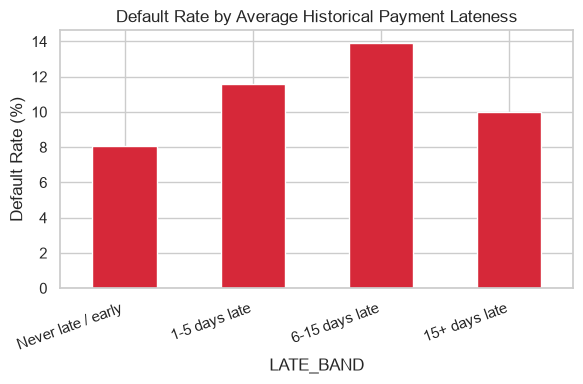

In [56]:
installments = tables.get("installments")
if installments is not None:
    installments["DAYS_LATE"] = installments["DAYS_ENTRY_PAYMENT"] - installments["DAYS_INSTALMENT"]
    avg_late = installments.groupby("SK_ID_CURR")["DAYS_LATE"].mean().rename("avg_days_late")

    df_late = df.merge(avg_late, on="SK_ID_CURR", how="left")
    df_late["LATE_BAND"] = pd.cut(
        df_late["avg_days_late"],
        bins=[-1000, 0, 5, 15, 1000],
        labels=["Never late / early", "1-5 days late", "6-15 days late", "15+ days late"]
    )
    rate = df_late.groupby("LATE_BAND", observed=True)["TARGET"].mean() * 100
    print("Default rate by average historical payment lateness:")
    print(rate)

    rate.plot(kind="bar", figsize=(6, 4), color="#D62839")
    plt.title("Default Rate by Average Historical Payment Lateness")
    plt.ylabel("Default Rate (%)")
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.savefig(CHART_DIR / "20_default_by_payment_lateness.png", dpi=120)
    plt.show()
else:
    print("installments_payments.csv not found in data/ - skipping.")

In [57]:
df_late["LATE_BAND"].value_counts()

LATE_BAND
Never late / early    283891
1-5 days late           3980
6-15 days late          2025
15+ days late           1736
Name: count, dtype: int64

Applicants with no external bureau history default more often (10.12%) than those with some history (7.73%) - this reflects the "thin file" problem in credit risk: no track record is itself a risk signal, not a safety signal. Prior refusal history behaves as expected - refused applicants default more (10.32% vs 6.98%). Payment lateness rises up to the 6-15 day band (13.93%), but the "15+ days late" band's lower rate (10.02%) is based on only 1,736 applicants (0.6% of the dataset) - too small a sample to treat as reliable. The clearer, better-supported result is that any history of lateness (1-5 or 6-15 days) meaningfully raises default rate compared to never being late.